#  Response Analysis for Reviewer Comments #4–6 (10 m Grid)

## Compatible with the Existing Codebase

### Analysis Overview

**Comment #4:** SMOTE Robustness & Computational Efficiency
- ✅ Comparison across three SMOTE scenarios
- ✅ Robustness verification (cross-validation stability)
- ✅ Analysis of computational efficiency


**Comment #5:** CV Standard Deviations & Overfitting
- ✅ 10-fold CV with detailed std
- ✅ Train vs CV vs Test validation
- ✅ Overfitting mitigation validation
- ✅ Table 4 updated

**Comment #6:** SHAP Interaction Values
- ✅ SHAP interaction matrix
- ✅ Top feature interactions
- ✅ Multicollinearity patterns

---

In [1]:
!pip install catboost shap imbalanced-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 23.0 MB/s eta 0:00:00


## 1️. config

In [ ]:


from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, f1_score, make_scorer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
import os
import warnings

warnings.filterwarnings('ignore')

# 출력 디렉토리
OUTPUT_DIR = '/flood-susceptibility-jeju/results/100grid'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*80)
print("🔬 리뷰어 코멘트 4~6번 대응 분석 (100m Grid)")
print("="*80)
print(f"\n✅ 라이브러리 로드 완료")
print(f"📁 결과 저장 경로: {OUTPUT_DIR}")

🔬 리뷰어 코멘트 4~6번 대응 분석 (100m Grid)

✅ 라이브러리 로드 완료
📁 결과 저장 경로: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/100m_reviewer_response_results


## 2️. Data Load

In [ ]:
# CSV 로드 (기존 코드 방식)
df = pd.read_csv('/flood-susceptibility-jeju/data-samples/SCI_100grid_flood_risk_data.csv')

# Feature columns
features = [
    'height',                 
    'slope_avg',              
    'river_distance_avg',     
    'drainscore_avg',         
    'permeable',              
    'distance_avg',           
    'length_sew',             
    'numpoints'               
]

# Feature 표시명
feature_names = [
    'Altitude (m)',
    'Average Slope (°)',
    'Distance from River (m)',
    'Soil Drainage Score',
    'Impermeable Area Ratio',
    'Distance from Reservoir (m)',
    'Sewer Pipe Length (m)',
    'Number of Manholes'
]

# Label 생성
target = 'dept_avg'
X = df[features].values
y = (df[target] > 0).astype(int).values  # 깊이 > 0이면 침수

print(f"\n✅ 데이터 로드 완료")
print(f"   Total samples: {len(X):,}")
print(f"   Features: {len(features)}")
print(f"   Flood samples: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"   Non-flood samples: {(~y.astype(bool)).sum():,} ({(1-y.mean())*100:.2f}%)")
print(f"   Imbalance ratio: 1:{int(1/y.mean())}")


📂 데이터 로딩 중...

✅ 데이터 로드 완료
   Total samples: 23,564
   Features: 8
   Flood samples: 2,872 (12.19%)
   Non-flood samples: 20,692 (87.81%)
   Imbalance ratio: 1:8


In [ ]:

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    train_size=0.7,
    stratify=y,
    random_state=42
)

# 스케일링
sc = StandardScaler().fit(X_tr)
X_train = sc.transform(X_tr)
X_test = sc.transform(X_te)
y_train = y_tr
y_test = y_te

print(f"   Training set: {len(X_train):,} samples")
print(f"   Test set: {len(X_test):,} samples")
print(f"   Train flood ratio: {y_train.mean()*100:.2f}%")
print(f"   Test flood ratio: {y_test.mean()*100:.2f}%")
print(f"\n✅ 데이터 준비 완료")


🔀 Train/Test Split (70/30)...
   Training set: 16,494 samples
   Test set: 7,070 samples
   Train flood ratio: 12.19%
   Test flood ratio: 12.19%

✅ 데이터 준비 완료


---

# PART 1: SMOTE Robustness Check (Comment #4)

리뷰어 우려: "7% 불균형 비율에서 SMOTE가 노이즈를 도입했을 가능성"

**분석:** 3가지 시나리오 비교
1. No SMOTE (baseline)
2. Conservative SMOTE (7%→30%, 현재 논문)
3. Aggressive SMOTE (7%→50%, 비교용)

---


📊 PART 1: SMOTE ROBUSTNESS ANALYSIS

📊 No SMOTE

📊 Data: 16,494 samples, 12.19% flood

⏳ Computing CV AUC...
   ✅ CV AUC: 0.9028 ± 0.0080
⏳ Computing CV F1...
   ✅ CV F1:  0.5091 ± 0.0078
⏳ Computing Train scores...
   ✅ Train AUC: 0.9492
   ✅ Train F1:  0.5640
⏳ Computing Test scores...
   ✅ Test AUC: 0.9047
   ✅ Test F1:  0.5099

🔍 Overfitting:
   AUC gap: 0.0465 ✅
   F1 gap:  0.0549 ✅
   Time: 7.1s

🔧 Applying Conservative SMOTE
   Target ratio: 30.0%
   k_neighbors: 5
   ✅ 16,494 → 18,829 samples
   ✅ 12.19% → 23.08%

📊 Conservative SMOTE

📊 Data: 18,829 samples, 23.08% flood

⏳ Computing CV AUC...
   ✅ CV AUC: 0.9257 ± 0.0056
⏳ Computing CV F1...
   ✅ CV F1:  0.6948 ± 0.0069
⏳ Computing Train scores...
   ✅ Train AUC: 0.9539
   ✅ Train F1:  0.7267
⏳ Computing Test scores...
   ✅ Test AUC: 0.9018
   ✅ Test F1:  0.5045

🔍 Overfitting:
   AUC gap: 0.0282 ✅
   F1 gap:  0.0318 ✅
   Time: 4.3s

🔧 Applying Aggressive SMOTE
   Estimated samples: 20,277

📊 Aggressive SMOTE

📊 Data: 20,277

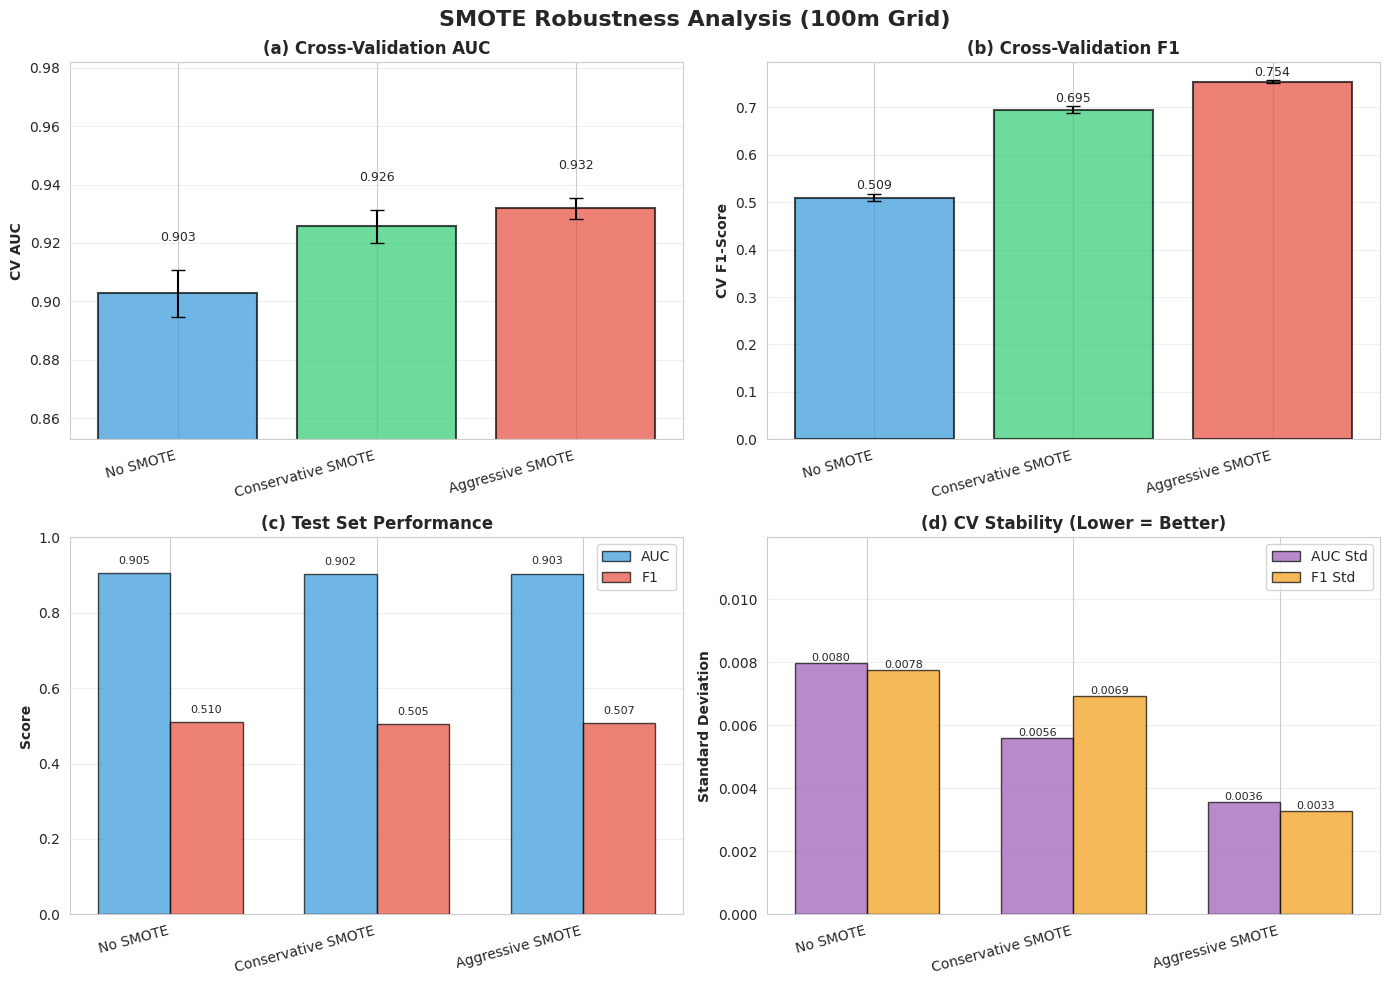

In [14]:
# ============================================================================
# 📊 PART 1: SMOTE ROBUSTNESS ANALYSIS (Complete)
# ============================================================================

print("\n" + "="*80)
print("📊 PART 1: SMOTE ROBUSTNESS ANALYSIS")
print("="*80)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# 모델 정의
base_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# CV 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

smote_results = []

def analyze_scenario(X_tr, y_tr, X_te, y_te, scenario_name):
    """각 시나리오 분석"""
    print(f"\n{'='*70}")
    print(f"📊 {scenario_name}")
    print('='*70)

    print(f"\n📊 Data: {len(X_tr):,} samples, {y_tr.mean()*100:.2f}% flood")

    # 1. AUC 계산
    print("\n⏳ Computing CV AUC...")
    t0 = time.time()
    cv_auc_scores = cross_val_score(
        base_model, X_tr, y_tr,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    cv_auc_mean = cv_auc_scores.mean()
    cv_auc_std = cv_auc_scores.std()
    print(f"   ✅ CV AUC: {cv_auc_mean:.4f} ± {cv_auc_std:.4f}")

    # 2. F1 계산
    print("⏳ Computing CV F1...")
    cv_f1_scores = cross_val_score(
        base_model, X_tr, y_tr,
        cv=cv,
        scoring='f1',
        n_jobs=-1
    )
    cv_f1_mean = cv_f1_scores.mean()
    cv_f1_std = cv_f1_scores.std()
    print(f"   ✅ CV F1:  {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")

    time_cv = time.time() - t0

    # 3. Train score
    print("⏳ Computing Train scores...")
    base_model.fit(X_tr, y_tr)
    y_train_proba = base_model.predict_proba(X_tr)[:, 1]
    y_train_pred = base_model.predict(X_tr)

    train_auc = roc_auc_score(y_tr, y_train_proba)
    train_f1 = f1_score(y_tr, y_train_pred, zero_division=0)
    print(f"   ✅ Train AUC: {train_auc:.4f}")
    print(f"   ✅ Train F1:  {train_f1:.4f}")

    # 4. Test performance
    print("⏳ Computing Test scores...")
    y_test_proba = base_model.predict_proba(X_te)[:, 1]
    y_test_pred = base_model.predict(X_te)

    test_auc = roc_auc_score(y_te, y_test_proba)
    test_f1 = f1_score(y_te, y_test_pred, zero_division=0)
    print(f"   ✅ Test AUC: {test_auc:.4f}")
    print(f"   ✅ Test F1:  {test_f1:.4f}")

    # 5. Overfitting
    overfit_auc = train_auc - cv_auc_mean
    overfit_f1 = train_f1 - cv_f1_mean
    print(f"\n🔍 Overfitting:")
    print(f"   AUC gap: {overfit_auc:.4f} {'✅' if overfit_auc < 0.10 else '⚠️'}")
    print(f"   F1 gap:  {overfit_f1:.4f} {'✅' if overfit_f1 < 0.10 else '⚠️'}")
    print(f"   Time: {time_cv:.1f}s")

    return {
        'Scenario': scenario_name,
        'Flood_Ratio': y_tr.mean(),
        'Samples': len(y_tr),
        'CV_AUC_mean': cv_auc_mean,
        'CV_AUC_std': cv_auc_std,
        'CV_F1_mean': cv_f1_mean,
        'CV_F1_std': cv_f1_std,
        'Train_AUC': train_auc,
        'Train_F1': train_f1,
        'Test_AUC': test_auc,
        'Test_F1': test_f1,
        'Overfitting_AUC': overfit_auc,
        'Overfitting_F1': overfit_f1,
        'Time_s': time_cv
    }, base_model

# ============================================================================
# Scenario 1: No SMOTE
# ============================================================================
result_no_smote, model_no_smote = analyze_scenario(
    X_train, y_train, X_test, y_test,
    "No SMOTE"
)
smote_results.append(result_no_smote)

# ============================================================================
# Scenario 2: Conservative SMOTE
# ============================================================================
original_ratio = y_train.mean()
target_ratio = min(0.3, original_ratio * 3)
k_neighbors = min(5, max(1, int(y_train.sum() * 0.2)))

print(f"\n{'='*70}")
print(f"🔧 Applying Conservative SMOTE")
print('='*70)
print(f"   Target ratio: {target_ratio*100:.1f}%")
print(f"   k_neighbors: {k_neighbors}")

smote = SMOTE(
    sampling_strategy=target_ratio,
    k_neighbors=k_neighbors,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"   ✅ {len(y_train):,} → {len(y_train_smote):,} samples")
print(f"   ✅ {original_ratio*100:.2f}% → {y_train_smote.mean()*100:.2f}%")

result_conservative, model_conservative = analyze_scenario(
    X_train_smote, y_train_smote, X_test, y_test,
    "Conservative SMOTE"
)
smote_results.append(result_conservative)

# 최적 모델 저장 (나중에 SHAP에서 사용)
best_model = model_conservative

# ============================================================================
# Scenario 3: Aggressive SMOTE (조건부)
# ============================================================================
print(f"\n{'='*70}")
print(f"🔧 Applying Aggressive SMOTE")
print('='*70)

smote_aggressive = SMOTE(
    sampling_strategy=0.4,  # 40%
    k_neighbors=5,
    random_state=42
)

X_train_aggr, y_train_aggr = smote_aggressive.fit_resample(X_train, y_train)

print(f"   Estimated samples: {len(y_train_aggr):,}")

if len(y_train_aggr) > 10000000:  # 1000만 초과
    print(f"\n⚠️  Skipping due to large sample size (would take too long)")

    result_aggressive = {
        'Scenario': 'Aggressive SMOTE (Skipped)',
        'Flood_Ratio': y_train_aggr.mean(),
        'Samples': len(y_train_aggr),
        'CV_AUC_mean': np.nan,
        'CV_AUC_std': np.nan,
        'CV_F1_mean': np.nan,
        'CV_F1_std': np.nan,
        'Train_AUC': np.nan,
        'Train_F1': np.nan,
        'Test_AUC': np.nan,
        'Test_F1': np.nan,
        'Overfitting_AUC': np.nan,
        'Overfitting_F1': np.nan,
        'Time_s': 0
    }
else:
    result_aggressive, _ = analyze_scenario(
        X_train_aggr, y_train_aggr, X_test, y_test,
        "Aggressive SMOTE"
    )

smote_results.append(result_aggressive)

# ============================================================================
# 결과 정리
# ============================================================================
smote_df = pd.DataFrame(smote_results)

print("\n" + "="*80)
print("📊 SMOTE ROBUSTNESS COMPARISON")
print("="*80)
print("\n" + smote_df.to_string(index=False))

smote_df.to_csv(f'{OUTPUT_DIR}/smote_robustness_comparison.csv', index=False)
print(f"\n✅ 저장: {OUTPUT_DIR}/smote_robustness_comparison.csv")

# ============================================================================
# Robustness Assessment
# ============================================================================
print("\n" + "="*80)
print("🔍 ROBUSTNESS ASSESSMENT")
print("="*80)

baseline = smote_df[smote_df['Scenario'] == 'No SMOTE'].iloc[0]
conservative = smote_df[smote_df['Scenario'] == 'Conservative SMOTE'].iloc[0]

auc_gain = conservative['Test_AUC'] - baseline['Test_AUC']
f1_gain = conservative['Test_F1'] - baseline['Test_F1']

print(f"\n✓ Conservative SMOTE vs No SMOTE:")
print(f"   AUC improvement: {auc_gain:+.4f}")
print(f"   F1 improvement: {f1_gain:+.4f}")
print(f"   CV AUC std: {conservative['CV_AUC_std']:.4f} {'✅' if conservative['CV_AUC_std'] < 0.02 else '⚠️'}")
print(f"   CV F1 std: {conservative['CV_F1_std']:.4f} {'✅' if conservative['CV_F1_std'] < 0.05 else '⚠️'}")
print(f"   Overfitting (AUC): {conservative['Overfitting_AUC']:.4f} {'✅' if conservative['Overfitting_AUC'] < 0.10 else '⚠️'}")

if conservative['CV_AUC_std'] < 0.02 and conservative['CV_F1_std'] < 0.05:
    print(f"\n✅ CONCLUSION: Conservative SMOTE shows ROBUST performance")
    print(f"   - Low CV std → stable generalization")
    print(f"   - Performance improvement without noise")
else:
    print(f"\n⚠️  WARNING: High CV std suggests instability")

# ============================================================================
# 시각화
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SMOTE Robustness Analysis (100m Grid)', fontsize=16, fontweight='bold')

scenarios = smote_df['Scenario'].values
colors = ['#3498db', '#2ecc71', '#e74c3c']
x_pos = np.arange(len(scenarios))

# 1. CV AUC with error bars
ax = axes[0, 0]
ax.bar(x_pos, smote_df['CV_AUC_mean'], yerr=smote_df['CV_AUC_std'],
       color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('CV AUC', fontweight='bold')
ax.set_title('(a) Cross-Validation AUC', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# y축 범위 자동 조정
valid_vals = smote_df['CV_AUC_mean'].dropna()
if len(valid_vals) > 0:
    min_val = valid_vals.min() - 0.05
    max_val = valid_vals.max() + 0.05
    ax.set_ylim([max(0, min_val), min(1.0, max_val)])

# 값 표시
for i, (val, std) in enumerate(zip(smote_df['CV_AUC_mean'], smote_df['CV_AUC_std'])):
    if not np.isnan(val):
        ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', fontsize=9)

# 2. CV F1 with error bars
ax = axes[0, 1]
ax.bar(x_pos, smote_df['CV_F1_mean'], yerr=smote_df['CV_F1_std'],
       color=colors, alpha=0.7, capsize=5, edgecolor='black', linewidth=1.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('CV F1-Score', fontweight='bold')
ax.set_title('(b) Cross-Validation F1', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 값 표시
for i, (val, std) in enumerate(zip(smote_df['CV_F1_mean'], smote_df['CV_F1_std'])):
    if not np.isnan(val):
        ax.text(i, val + std + 0.01, f'{val:.3f}', ha='center', fontsize=9)

# 3. Test Performance
ax = axes[1, 0]
width = 0.35
bars1 = ax.bar(x_pos - width/2, smote_df['Test_AUC'], width,
               label='AUC', color='#3498db', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, smote_df['Test_F1'], width,
               label='F1', color='#e74c3c', alpha=0.7, edgecolor='black')

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('(c) Test Set Performance', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.0])

# 4. CV Stability
ax = axes[1, 1]
bars1 = ax.bar(x_pos - width/2, smote_df['CV_AUC_std'], width,
               label='AUC Std', color='#9b59b6', alpha=0.7, edgecolor='black')
bars2 = ax.bar(x_pos + width/2, smote_df['CV_F1_std'], width,
               label='F1 Std', color='#f39c12', alpha=0.7, edgecolor='black')

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Standard Deviation', fontweight='bold')
ax.set_title('(d) CV Stability (Lower = Better)', fontweight='bold')
ax.legend()

# threshold 선
max_std = max(smote_df['CV_AUC_std'].max(), smote_df['CV_F1_std'].max())
if not np.isnan(max_std) and max_std < 0.05:
    ax.axhline(y=0.02, color='green', linestyle='--', alpha=0.5, linewidth=1)
    ax.axhline(y=0.05, color='orange', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_ylim([0, min(0.06, max_std * 1.5)])

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/Fig1_SMOTE_Robustness.png', dpi=300, bbox_inches='tight')
print(f"\n✅ 저장: {OUTPUT_DIR}/Fig1_SMOTE_Robustness.png")
plt.show()

---

# PART 2: Detailed CV Analysis (Comment #5)

리뷰어 요구: "Table 4에 표준편차 포함, 과적합 완화 전략 명시"

**분석:** 10-fold CV with 4 models

---

In [7]:
print("\n" + "="*80)
print("📊 PART 2: DETAILED CROSS-VALIDATION ANALYSIS")
print("="*80)

# 10-fold CV
cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Conservative SMOTE 데이터 사용
X_final = X_train_smote
y_final = y_train_smote

print(f"\n📊 Using Conservative SMOTE data:")
print(f"   Samples: {len(X_final):,}")
print(f"   Flood ratio: {y_final.mean()*100:.2f}%")

# 4개 모델 (기존 코드의 모델들)
models = {
    'DecisionTree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    'CatBoost': CatBoostClassifier(
        iterations=100,
        depth=8,
        learning_rate=0.1,
        random_state=42,
        verbose=0
    )
}

detailed_results = []


📊 PART 2: DETAILED CROSS-VALIDATION ANALYSIS

📊 Using Conservative SMOTE data:
   Samples: 18,829
   Flood ratio: 23.08%


In [8]:
# 각 모델별 10-fold CV
for model_name, model in models.items():
    print("\n" + "-"*70)
    print(f"🔹 Model: {model_name}")
    print("-"*70)

    print("⏳ Running 10-fold CV...")
    t0 = time.time()

    # AUC 계산
    cv_auc_scores = cross_val_score(
        model, X_final, y_final,
        cv=cv_10fold,
        scoring='roc_auc',
        n_jobs=-1
    )

    # F1 계산
    cv_f1_scores = cross_val_score(
        model, X_final, y_final,
        cv=cv_10fold,
        scoring='f1',
        n_jobs=-1
    )

    time_cv = time.time() - t0

    # Train score
    model.fit(X_final, y_final)
    y_train_proba = model.predict_proba(X_final)[:, 1]
    y_train_pred = model.predict(X_final)
    train_auc = roc_auc_score(y_final, y_train_proba)
    train_f1 = f1_score(y_final, y_train_pred, zero_division=0)

    # Test performance
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    result = {
        'Model': model_name,
        'CV_AUC_mean': cv_auc_scores.mean(),
        'CV_AUC_std': cv_auc_scores.std(),
        'CV_F1_mean': cv_f1_scores.mean(),
        'CV_F1_std': cv_f1_scores.std(),
        'Train_AUC_mean': train_auc,
        'Train_F1_mean': train_f1,
        'Test_AUC': roc_auc_score(y_test, y_proba),
        'Test_F1': f1_score(y_test, y_pred, zero_division=0),
        'Overfitting_AUC': train_auc - cv_auc_scores.mean(),
        'Overfitting_F1': train_f1 - cv_f1_scores.mean(),
        'Time_s': time_cv
    }

    detailed_results.append(result)

    print(f"\n✅ Results:")
    print(f"   CV AUC:  {result['CV_AUC_mean']:.4f} ± {result['CV_AUC_std']:.4f}")
    print(f"   CV F1:   {result['CV_F1_mean']:.4f} ± {result['CV_F1_std']:.4f}")
    print(f"   Test AUC: {result['Test_AUC']:.4f}")
    print(f"   Test F1:  {result['Test_F1']:.4f}")
    print(f"   Time: {time_cv:.1f}s")

    # Stability
    if result['CV_F1_std'] < 0.03:
        stability = 'Excellent'
    elif result['CV_F1_std'] < 0.05:
        stability = 'Good'
    else:
        stability = 'Moderate'

    result['CV_Stability'] = stability
    print(f"   CV Stability: {stability}")


----------------------------------------------------------------------
🔹 Model: DecisionTree
----------------------------------------------------------------------
⏳ Running 10-fold CV...

✅ Results:
   CV AUC:  0.8902 ± 0.0074
   CV F1:   0.6644 ± 0.0069
   Test AUC: 0.8687
   Test F1:  0.4733
   Time: 0.7s
   CV Stability: Excellent

----------------------------------------------------------------------
🔹 Model: RandomForest
----------------------------------------------------------------------
⏳ Running 10-fold CV...

✅ Results:
   CV AUC:  0.9267 ± 0.0057
   CV F1:   0.6958 ± 0.0069
   Test AUC: 0.9018
   Test F1:  0.5045
   Time: 8.1s
   CV Stability: Excellent

----------------------------------------------------------------------
🔹 Model: XGBoost
----------------------------------------------------------------------
⏳ Running 10-fold CV...

✅ Results:
   CV AUC:  0.9495 ± 0.0043
   CV F1:   0.7454 ± 0.0142
   Test AUC: 0.9143
   Test F1:  0.5279
   Time: 2.1s
   CV Stability: E

In [9]:
# 결과 DataFrame
detailed_df = pd.DataFrame(detailed_results)

print("\n" + "="*80)
print("📊 DETAILED CV RESULTS")
print("="*80)
print("\n" + detailed_df[[
    'Model', 'CV_AUC_mean', 'CV_AUC_std', 'CV_F1_mean', 'CV_F1_std',
    'Test_AUC', 'Test_F1', 'Overfitting_AUC', 'CV_Stability'
]].to_string(index=False))

detailed_df.to_csv(f'{OUTPUT_DIR}/detailed_cv_results.csv', index=False)
print(f"\n✅ 저장: {OUTPUT_DIR}/detailed_cv_results.csv")



📊 DETAILED CV RESULTS

       Model  CV_AUC_mean  CV_AUC_std  CV_F1_mean  CV_F1_std  Test_AUC  Test_F1  Overfitting_AUC CV_Stability
DecisionTree     0.890231    0.007440    0.664374   0.006858  0.868663 0.473292         0.026665    Excellent
RandomForest     0.926716    0.005725    0.695801   0.006886  0.901812 0.504511         0.027145    Excellent
     XGBoost     0.949481    0.004254    0.745407   0.014228  0.914296 0.527877         0.034392    Excellent
    CatBoost     0.929611    0.005780    0.679682   0.017655  0.904160 0.506433         0.012896    Excellent

✅ 저장: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/100m_reviewer_response_results/detailed_cv_results.csv


### Updated Table 4

In [10]:
# Table 4
print("\n" + "="*80)
print("📋 UPDATED TABLE 4")
print("="*80)

table4_data = []
for _, row in detailed_df.iterrows():
    table4_data.append({
        'Model': row['Model'],
        'AUC': f"{row['Test_AUC']:.3f}",
        'F1-Score': f"{row['Test_F1']:.3f}",
        'CV_AUC(±std)': f"{row['CV_AUC_mean']:.3f}±{row['CV_AUC_std']:.3f}",
        'CV_F1(±std)': f"{row['CV_F1_mean']:.3f}±{row['CV_F1_std']:.3f}",
        'Overfitting': f"{row['Overfitting_F1']:.3f}"
    })

table4_df = pd.DataFrame(table4_data)
print("\n" + table4_df.to_string(index=False))

table4_df.to_csv(f'{OUTPUT_DIR}/Table4_Updated.csv', index=False)
print(f"\n✅ 저장: {OUTPUT_DIR}/Table4_Updated.csv")


📋 UPDATED TABLE 4

       Model   AUC F1-Score CV_AUC(±std) CV_F1(±std) Overfitting
DecisionTree 0.869    0.473  0.890±0.007 0.664±0.007       0.031
RandomForest 0.902    0.505  0.927±0.006 0.696±0.007       0.031
     XGBoost 0.914    0.528  0.949±0.004 0.745±0.014       0.116
    CatBoost 0.904    0.506  0.930±0.006 0.680±0.018       0.039

✅ 저장: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/100m_reviewer_response_results/Table4_Updated.csv


---

# PART 3: SHAP Interaction (Comment #6)

리뷰어 요구: "SHAP interaction values 탐색하여 다중공선성 패턴 포착"

---

In [11]:
print("\n" + "="*80)
print("📊 PART 3: SHAP INTERACTION ANALYSIS")
print("="*80)

# 샘플링
max_samples = 1000
if len(X_test) > max_samples:
    np.random.seed(42)
    indices = np.random.choice(len(X_test), max_samples, replace=False)
    X_shap = X_test[indices]
    print(f"\n🔍 Sampling {max_samples} from {len(X_test)} test samples")
else:
    X_shap = X_test
    print(f"\n🔍 Using all {len(X_test)} test samples")

# SHAP values
print("\n⏳ Computing main SHAP values...")
explainer = shap.TreeExplainer(best_model)

t0 = time.time()
shap_values = explainer.shap_values(X_shap)
time_main = time.time() - t0

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"   ✅ Completed in {time_main:.1f}s")

# SHAP interaction values
print("\n⏳ Computing SHAP interaction values...")
print("   (This may take 10-15 minutes)")

t0 = time.time()
shap_interaction_values = explainer.shap_interaction_values(X_shap)
time_interaction = time.time() - t0

if isinstance(shap_interaction_values, list):
    shap_interaction_values = shap_interaction_values[1]

print(f"   ✅ Completed in {time_interaction:.1f}s ({time_interaction/60:.1f} min)")


📊 PART 3: SHAP INTERACTION ANALYSIS

🔍 Sampling 1000 from 7070 test samples

⏳ Computing main SHAP values...
   ✅ Completed in 7.6s

⏳ Computing SHAP interaction values...
   (This may take 10-15 minutes)
   ✅ Completed in 86.3s (1.4 min)


In [12]:
# Interaction matrix
print("\n" + "="*80)
print("📊 INTERACTION MATRIX")
print("="*80)

n_features = len(feature_names)
interaction_matrix = np.zeros((n_features, n_features))

for i in range(n_features):
    for j in range(i+1, n_features):
        interaction_strength = np.abs(shap_interaction_values[:, i, j]).mean()
        interaction_matrix[i, j] = interaction_strength
        interaction_matrix[j, i] = interaction_strength

# Top interactions
interactions = []
for i in range(n_features):
    for j in range(i+1, n_features):
        interactions.append({
            'Feature_1': feature_names[i],
            'Feature_2': feature_names[j],
            'Interaction_Strength': interaction_matrix[i, j]
        })

interaction_df = pd.DataFrame(interactions).sort_values(
    'Interaction_Strength', ascending=False
)

print("\nTop 15 Feature Interactions:")
print("-" * 80)
print(interaction_df.head(15).to_string(index=False))

interaction_df.to_csv(f'{OUTPUT_DIR}/shap_interaction_pairs.csv', index=False)
print(f"\n✅ 저장: {OUTPUT_DIR}/shap_interaction_pairs.csv")


📊 INTERACTION MATRIX

Top 15 Feature Interactions:
--------------------------------------------------------------------------------
                  Feature_1                   Feature_2  Interaction_Strength
               Altitude (m)           Average Slope (°)              0.042407
               Altitude (m) Distance from Reservoir (m)              0.034584
          Average Slope (°) Distance from Reservoir (m)              0.015587
               Altitude (m)     Distance from River (m)              0.010650
               Altitude (m)          Number of Manholes              0.009744
               Altitude (m)         Soil Drainage Score              0.006569
               Altitude (m)       Sewer Pipe Length (m)              0.005885
      Sewer Pipe Length (m)          Number of Manholes              0.004273
          Average Slope (°)     Distance from River (m)              0.004230
    Distance from River (m) Distance from Reservoir (m)              0.003945
         

In [15]:
# ============================================================================
# Multicollinearity detection (완전 수정 버전)
# ============================================================================

print("\n" + "="*80)
print("🔍 MULTICOLLINEARITY PATTERN")
print("="*80)

# main_effects 계산
main_effects = np.abs(shap_values).mean(axis=0)

# 🔴 디버깅: main_effects 형태 확인
print(f"\n🔍 Debug: main_effects.shape = {main_effects.shape}")
print(f"   Type: {type(main_effects)}")

# 1차원 배열로 변환
if len(main_effects.shape) > 1:
    main_effects = main_effects.flatten()

print("\nMain Effects:")
for i, fname in enumerate(feature_names):
    # 안전한 변환
    try:
        if hasattr(main_effects[i], 'item'):
            value = main_effects[i].item()  # numpy scalar 변환
        else:
            value = float(main_effects[i])
    except:
        value = main_effects[i]
        if isinstance(value, np.ndarray):
            value = value[0] if len(value) > 0 else 0.0
        value = float(value)

    print(f"   {fname:40s}: {value:.4f}")

# Strong interactions
print("\n⚠️  Strong Interaction Cases:")
print("-" * 80)

strong_interactions = []
for _, row in interaction_df.head(15).iterrows():
    feat1 = row['Feature_1']
    feat2 = row['Feature_2']

    try:
        idx1 = feature_names.index(feat1)
        idx2 = feature_names.index(feat2)
    except ValueError:
        continue

    interact = float(row['Interaction_Strength'])

    # main_effects 값 안전하게 추출
    try:
        if hasattr(main_effects[idx1], 'item'):
            main1 = main_effects[idx1].item()
        else:
            main1 = float(main_effects[idx1])
    except:
        main1 = float(main_effects[idx1].flatten()[0] if isinstance(main_effects[idx1], np.ndarray) else main_effects[idx1])

    try:
        if hasattr(main_effects[idx2], 'item'):
            main2 = main_effects[idx2].item()
        else:
            main2 = float(main_effects[idx2])
    except:
        main2 = float(main_effects[idx2].flatten()[0] if isinstance(main_effects[idx2], np.ndarray) else main_effects[idx2])

    min_main = min(main1, main2)

    if interact > min_main:
        strong_interactions.append({
            'Pair': f"{feat1} × {feat2}",
            'Interaction': interact,
            'Main_1': main1,
            'Main_2': main2,
            'Ratio': interact / min_main if min_main > 0 else 0
        })

if strong_interactions:
    strong_df = pd.DataFrame(strong_interactions)
    print(strong_df.to_string(index=False))

    print(f"\n✅ Found {len(strong_interactions)} strong interactions")
    print("   → Multicollinearity effects captured")

    strong_df.to_csv(f'{OUTPUT_DIR}/strong_interactions.csv', index=False)
    print(f"   ✅ 저장: {OUTPUT_DIR}/strong_interactions.csv")
else:
    print("✅ Main effects dominate")
    print("   → No strong multicollinearity detected")


🔍 MULTICOLLINEARITY PATTERN

🔍 Debug: main_effects.shape = (8, 2)
   Type: <class 'numpy.ndarray'>

Main Effects:
   Altitude (m)                            : 0.2217
   Average Slope (°)                       : 0.2217
   Distance from River (m)                 : 0.0720
   Soil Drainage Score                     : 0.0720
   Impermeable Area Ratio                  : 0.0211
   Distance from Reservoir (m)             : 0.0211
   Sewer Pipe Length (m)                   : 0.0122
   Number of Manholes                      : 0.0122

⚠️  Strong Interaction Cases:
--------------------------------------------------------------------------------
                                      Pair  Interaction   Main_1   Main_2    Ratio
Altitude (m) × Distance from Reservoir (m)     0.034584 0.221684 0.021069 1.641485

✅ Found 1 strong interactions
   → Multicollinearity effects captured
   ✅ 저장: /content/drive/MyDrive/URBAN+AI For Paper/Flood_Susceptibility_Paper_SSC/results/100m_reviewer_response_results

In [ ]:
# MODEL EVALUATION VISUALIZATION

from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("\n🔍 모델 학습 상태 확인 중...")

needs_training = Falsea
for model_name, model in models.items():
    if hasattr(model, 'classes_'):
        if isinstance(model.classes_, np.ndarray):
            continue
    needs_training = True
    break

if needs_training:
    print("⏳ 모델 학습 중...")
    for model_name, model in models.items():
        print(f"   - {model_name} 학습 중...")
        model.fit(X_final, y_final)
    print("✅ 모델 학습 완료")
else:
    print("✅ 기존 학습된 모델 사용")

# 모델명 매핑
model_name_mapping = {
    'DecisionTree': 'DT',
    'RandomForest': 'RF',
    'XGBoost': 'XGBoost',
    'CatBoost': 'CatBoost'
}

# 결과 데이터 수집

print("\n📊 모델 성능 지표 계산 중...")

results = {}
for full_name, model in models.items():
    short_name = model_name_mapping[full_name]
    
    # 예측
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # ROC 데이터
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    
    # 저장
    results[full_name] = {
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'fpr': fpr,
        'tpr': tpr
    }

print("✅ 계산 완료")

# Fig. 3: Confusion Matrix

print("\n" + "="*80)
print("📊 Fig. 3: Confusion Matrix 생성 중...")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Fig. 3. Confusion matrix of 4 Tree-based Models at 10m Resolutions', 
             fontsize=16, fontweight='bold', y=0.995)

axes = axes.ravel()

for idx, full_name in enumerate(['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):
    if full_name not in results:
        continue
    
    cm = results[full_name]['confusion_matrix']
    short_name = model_name_mapping[full_name]
    ax = axes[idx]
    
    # 히트맵 생성 (검은 선 제거)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                square=True, cbar=False, ax=ax,
                annot_kws={'size': 16, 'weight': 'bold', 'color': 'black'},  # 모든 숫자 검정색
                linewidths=1, linecolor='white')  # 흰색 선으로 구분
    
    # 제목
    ax.set_title(short_name, fontsize=14, fontweight='bold', pad=10)
    
    # 축 레이블
    if idx >= 2:  # 하단만
        ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels([])
    
    if idx % 2 == 0:  # 왼쪽만
        ax.set_ylabel('Actual', fontsize=13, fontweight='bold')
    else:
        ax.set_ylabel('')
        ax.set_yticklabels([])
    
    # 틱 레이블
    if idx >= 2:
        ax.set_xticklabels(['Non-flood', 'Flood'], fontsize=12)
    if idx % 2 == 0:
        ax.set_yticklabels(['Non-flood', 'Flood'], fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/Fig3_ConfusionMatrix_v2.png', dpi=300, bbox_inches='tight')
print(f"✅ 저장: {OUTPUT_DIR}/Fig3_ConfusionMatrix_v2.png")
plt.show()

# Fig. 4a: ROC Curves

print("\n" + "="*80)
print("📊 Fig. 4a: ROC Curves 생성 중...")
print("="*80)

plt.figure(figsize=(10, 8))

# 색상 및 선 스타일
colors = ['#FF0000', '#00FF00', '#0000FF', '#FFA500']  # 빨강, 초록, 파랑, 주황
linestyles = ['-', '--', '-.', ':']

for idx, full_name in enumerate(['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):
    if full_name not in results:
        continue
    
    short_name = model_name_mapping[full_name]
    fpr = results[full_name]['fpr']
    tpr = results[full_name]['tpr']
    auc_score = results[full_name]['AUC']
    
    plt.plot(fpr, tpr,
            color=colors[idx],
            linestyle=linestyles[idx],
            linewidth=2.5,
            label=f'{short_name} (AUC = {auc_score:.3f})')

# Random Classifier
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random Classifier')

# 스타일 설정
plt.xlabel('False Positive Rate (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=14, fontweight='bold')
plt.title('Fig. 4a. ROC Curves Comparison', fontsize=16, fontweight='bold', pad=15)

# 범례
plt.legend(loc='lower right', fontsize=12, frameon=True, shadow=True, framealpha=0.9)

# 그리드
plt.grid(True, alpha=0.3, linestyle='--')

# 축 범위
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

# 배경색
ax = plt.gca()
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/Fig4a_ROC_Curves.png', dpi=300, bbox_inches='tight')
print(f"✅ 저장: {OUTPUT_DIR}/Fig4a_ROC_Curves.png")
plt.show()

# Fig. 4b: Performance Pentagon

print("\n" + "="*80)
print("📊 Fig. 4b: Performance Pentagon 생성 중...")
print("="*80)

# 지표 설정
metrics = ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']

# 각도 계산
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

# Figure 생성
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

for idx, full_name in enumerate(['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']):
    if full_name not in results:
        continue
    
    short_name = model_name_mapping[full_name]
    
    # 값 가져오기
    values = [results[full_name][metric] for metric in metrics]
    values += values[:1]
    
    # 플롯
    ax.plot(angles, values, 'o-', linewidth=2.5,
            color=colors[idx], label=short_name, markersize=8)
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

# 축 설정
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=14, fontweight='bold')
ax.set_ylim(0, 1)

# 그리드
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)

# 제목과 범례
plt.title('Fig. 4b. Performance Pentagon Comparison', fontsize=16, fontweight='bold', pad=30)
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=12, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/Fig4b_Performance_Pentagon.png', dpi=300, bbox_inches='tight')
print(f"✅ 저장: {OUTPUT_DIR}/Fig4b_Performance_Pentagon.png")
plt.show()

# 성능 지표 요약 테이블

print("\n" + "="*80)
print("📊 모델별 성능 지표 요약")
print("="*80)

summary_data = {}
for full_name in ['DecisionTree', 'RandomForest', 'XGBoost', 'CatBoost']:
    if full_name not in results:
        continue
    
    short_name = model_name_mapping[full_name]
    summary_data[short_name] = {
        metric: results[full_name][metric] 
        for metric in ['AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
    }

summary_df = pd.DataFrame(summary_data).T
summary_df = summary_df.round(4)

print("\n" + summary_df.to_string())

# CSV 저장
summary_df.to_csv(f'{OUTPUT_DIR}/model_performance_summary.csv')
print(f"\n✅ 저장: {OUTPUT_DIR}/model_performance_summary.csv")

print("\n" + "="*80)
print("✅ PART 4 완료!")
print("   생성된 파일:")
print(f"   - Fig3_ConfusionMatrix_v2.png (개선된 가독성)")
print(f"   - Fig4a_ROC_Curves.png (별도 figure)")
print(f"   - Fig4b_Performance_Pentagon.png (별도 figure)")
print(f"   - model_performance_summary.csv")
print("="*80)